In [36]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

*Loads X Y, train-test*

In [37]:
X_train = pd.read_csv(f"../data/processed/X_train_processed.csv")
y_train = pd.read_csv(f"../data/processed/y_train_processed.csv").values.ravel()

X_test = pd.read_csv(f"../data/processed/X_test_processed.csv")
y_test = pd.read_csv(f"../data/processed/y_test_processed.csv").values.ravel()

*with Algorithms Tuning* `class_weight='balanced`

In [38]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced'),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, verbosity=-1, class_weight='balanced'
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, eval_metric="mlogloss"
    ),
}

In [39]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_f1 = f1_score(y_train, train_pred, average="macro")
    test_f1 = f1_score(y_test, test_pred, average="macro")

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Macro-F1": train_f1,
        "Test Macro-F1": test_f1,
        "Test Weighted-F1": f1_score(y_test, test_pred, average="weighted"),
        "Train-Test Gap": train_f1 - test_f1,
    })
    print(f"{name} done — Test Macro-F1: {test_f1:.3f}, Gap: {train_f1 - test_f1:.3f}")

results_df = pd.DataFrame(results).round(4).sort_values("Test Macro-F1", ascending=False)
results_df

Decision Tree done — Test Macro-F1: 0.501, Gap: 0.004
SVM done — Test Macro-F1: 0.046, Gap: -0.009


/Users/nurulhudaadamishaq/Documents/disaster-type-prediction/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression done — Test Macro-F1: 0.802, Gap: 0.015
Random Forest done — Test Macro-F1: 0.885, Gap: 0.115
LightGBM done — Test Macro-F1: 0.906, Gap: 0.080
XGBoost done — Test Macro-F1: 0.911, Gap: 0.084


,Model,Train Accuracy,Test Accuracy,Train Macro-F1,Test Macro-F1,Test Weighted-F1,Train-Test Gap
5,XGBoost,0.9976,0.9597,0.9951,0.9110,0.9585,0.0840
4,LightGBM,0.9920,0.9502,0.9861,0.9057,0.9520,0.0805
3,Random Forest,0.9997,0.9531,0.9994,0.8848,0.9490,0.1146
2,Logistic Regression,0.8616,0.8486,0.8167,0.8016,0.8673,0.0151
0,Decision Tree,0.8017,0.7957,0.5045,0.5005,0.7673,0.0040
1,SVM,0.0466,0.0518,0.0377,0.0462,0.0310,-0.0085


In [40]:
# StratifiedKFold 5-Fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Data loaded. Shapes: X_train {X_train.shape}, y_train {y_train.shape}")

Data loaded. Shapes: X_train (13979, 39), y_train (13979,)



# =====================================================================
# TUNING CONFIGURATION FOR LIGHTGBM + SMOTE
# =====================================================================

In [41]:
# สร้าง Pipeline ที่รวม SMOTE และ LightGBM เข้าด้วยกัน
lgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LGBMClassifier(random_state=42, n_jobs=-1, verbosity=-1, num_leaves=31))
])

# Parameter Grid สำหรับ LightGBM (ระบุชื่อ 'clf__' นำหน้าพารามิเตอร์ของโมเดล)
lgb_param_grid = {
    'clf__n_estimators':[100, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [3, 5, 7]
}

# นิยาม GridSearchCV สำหรับ LightGBM
lgb_search = GridSearchCV(
    estimator=lgb_pipeline,
    param_grid=lgb_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)


# =====================================================================
# TUNING CONFIGURATION FOR XGBOOST + BASELINE
# =====================================================================

In [51]:
# สร้างโมเดล XGBoost โดยตรง (ไม่ต้องใช้ Pipeline เนื่องจากผลทดสอบไม่ต้องพึ่งพา SMOTE)
# xgb_pipeline = ImbPipeline([
#     ('smote', SMOTE(random_state=42)),
#     ('xgb', XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'))
# ])
xgb_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss')

# Parameter Grid สำหรับ XGBoost
xgb_param_grid = {
    'n_estimators':[100, 200, 300] ,
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':[3, 5, 7],
    'subsample': [0.8, 1.0]
}

# นิยาม GridSearchCV สำหรับ XGBoost
xgb_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)


In [ ]:
lgb_search.fit(X_train, y_train)
print(f"LightGBM Best CV F1-Macro: {lgb_search.best_score_:.6f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API.

LightGBM Best CV F1-Macro: 0.912301
Fitting 5 folds for each of 54 candidates, totalling 270 fits
XGBoost Best CV F1-Macro: 0.912299


In [52]:
xgb_search.fit(X_train, y_train)
print(f"XGBoost Best CV F1-Macro: {xgb_search.best_score_:.6f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.10/3.10.19_1/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API.

XGBoost Best CV F1-Macro: 0.913050


# =====================================================================
# MODEL COMPARISON 
# =====================================================================

In [53]:
if lgb_search.best_score_ > xgb_search.best_score_:
    print(f"FINAL: LightGBM + SMOTE | CV F1-Macro: {lgb_search.best_score_:.6f}")
    print(f"Best Hyperparameters: {lgb_search.best_params_}")
    final_model = lgb_search.best_estimator_
else:
    print(f"FINAL: XGBoost + Baseline | CV F1-Macro: {xgb_search.best_score_:.6f}")
    print(f"Best Hyperparameters: {xgb_search.best_params_}")
    final_model = xgb_search.best_estimator_
print("=" * 60)

FINAL: XGBoost + Baseline | CV F1-Macro: 0.913050
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


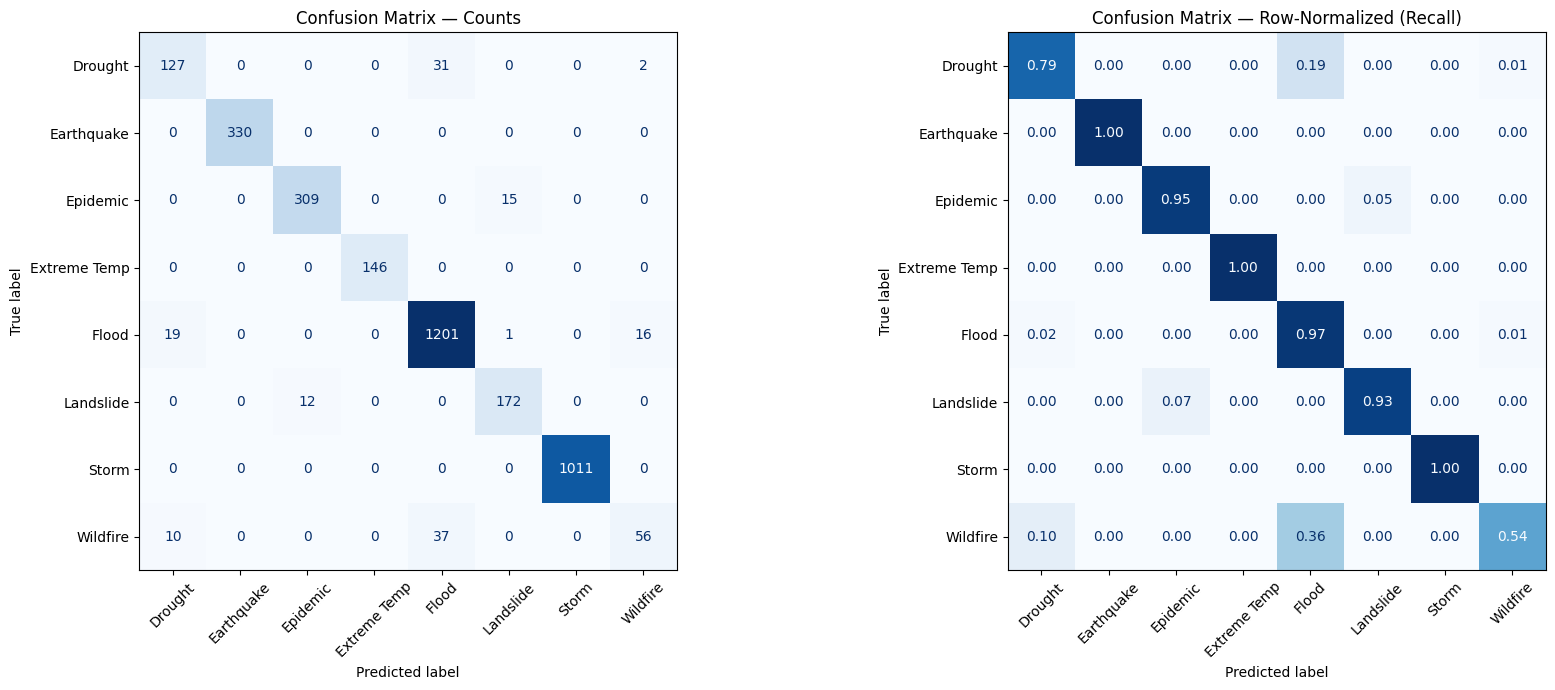

In [54]:
# Load the label encoder used to encode the target
label_encoder = joblib.load(f"../data/processed/label_encoder.pkl")
class_names = label_encoder.classes_

# Predict on test set with the final tuned model
y_test_pred = final_model.predict(X_test)

# Raw confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Counts
disp_counts = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp_counts.plot(ax=axes[0], cmap="Blues", xticks_rotation=45, colorbar=False)
axes[0].set_title("Confusion Matrix — Counts")

# Row-normalized (recall per class) — more informative given class imbalance
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(ax=axes[1], cmap="Blues", xticks_rotation=45, colorbar=False, values_format=".2f")
axes[1].set_title("Confusion Matrix — Row-Normalized (Recall)")

plt.tight_layout()
plt.savefig(f"../models/confusion_matrix_final_model.png", dpi=150, bbox_inches="tight")
plt.show()

# Save Model

In [55]:
output_path = f"../models/final_best_disaster_model.pkl"
joblib.dump(final_model, output_path)

['../models/final_best_disaster_model.pkl']